# Machine Learning in Python - Project 

Due Friday, Apr 10th by 4 pm.

*Include contributors names here*

## Setup

*Install any packages here, define any functions if neeed, and load data*

In [1]:
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from scipy.stats import chi2_contingency
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)


In [2]:
# Load data  
df_raw = pd.read_csv("unicef_malawi.csv")

print("Dataset shape:", df_raw.shape)
print("\nData types:")
print(df_raw.dtypes)

Dataset shape: (13162, 87)

Data types:
HH1     float64
HH2     float64
LN      float64
FS4     float64
CB3     float64
         ...   
WS7         str
WS11        str
WS14        str
WS15        str
HW5         str
Length: 87, dtype: object


# Introduction

*This section should include a brief introduction to the task and the data (assume this is a report you are delivering to a professional body (e.g. UNICEF)).*

*Briefly outline the approaches being used and the conclusions that you are able to draw.*

### 1.1 Task Overview and Objectives
This study aims to utilize high-dimensional survey data to identify and quantify the core socioeconomic and family determinants of **Childhood depression** in Malawi in order to develop a classification and predictive model. This report presents a robust feature selection and predictive modeling framework designed to identify the most statistically significant predictors of depressive symptoms, thereby providing precise intervention guidance for organizations such as **UNICEF**.

### 1.2 Data Description
The data set is from **Multiple Indicator Cluster Survey (MICS)**.

**Data Source:** This dataset is a simplified, cleaned subset focusing on the situation in Malawi in 2019–2020, integrating information at the child, mother, and family levels.

**Feature Dimensions:** It includes variables related to demographics, education, labor, family environment, and living conditions, allowing for a comprehensive assessment of factors related to child well-being.

**Target Variable Transformation:** The original survey question (FCF26) recorded the frequency with which children felt anxious or depressed. As required by the project, this variable was simplified to a binary outcome, designed to distinguish between "no signs of depression" and "any degree of depressive tendency."


### 1.3 Methodological Approach

To extract the most explanatory model from numerous variables, we implemented the following multi-stage analysis process:

#### **First stage：Feature Selection**

1. **Numerical and ordered variables**：Using **Mutual Information** can capture complex nonlinear relationships between variables.

2. **Categorical Variables (Nominal):** A **Chi-square test($\chi^2$ Test)** was used. This ensures that the qualitative factors entering the model have statistically significant distributional differences from the target variable.

#### **Second stage: (Baseline Modeling)**

Build **Logistic Regression** as baseline model.

* **Formula**：
$$\ln\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1X_1 + \beta_2X_2 + \dots + \beta_kX_k$$



### 1.4 Preliminary Conclusions


# Exploratory Data Analysis and Feature Engineering

This study uses the UNICEF Malawi dataset for analysis. The dataset includes variables on child background, household environment, maternal characteristics, violence-related factors, and sanitation conditions. These factors are used to investigate childhood depression.
## 2.1 Dataset Overview
To improve the structure and interpretability of the dataset, the variables were first grouped according to their themes and definitions. An initial check of data types and missingness was conducted to identify potential data quality issues and provide a basis for later data cleaning and feature selection.

In [3]:
df = df_raw.copy()
# Variable groups
child_background_vars = ['CB3','CB4','CB5A','CB5B','CB7','CB11','HH6','HH7','HL4','ethnicity','wscore']
child_labour_vars = ['CL2','CL3','CL12','CL13']
child_discipline_vars = ['FCD2A','FCD2B','FCD2C','FCD2D','FCD2E','FCD2F','FCD2G','FCD2H','FCD2I','FCD2J','FCD2K','FCD5']
child_functioning_vars = ['FCF26']
mother_background_vars = ['WB4', 'WB5', 'WB6A', 'WB6B', 'WB14']
domestic_violence_vars = ['DV1A', 'DV1B', 'DV1C', 'DV1D', 'DV1E']
victimization_vars = ['VT1', 'VT9', 'VT20', 'VT21', 'VT22A', 'VT22B', 'VT22C', 'VT22D', 'VT22E', 'VT22F', 'VT22X']
marriage_union_vars = ['MSTATUS', 'MA2', 'MA3']
adult_functioning_vars = ['disability','AF10','AF11','AF12']
tobacco_alcohol_vars = ['TA1','TA14']
life_satisfaction_vars = ['LS1','LS2','LS3','LS4']
fertility_vars = ['CSURV','CDEAD']
household_characteristics_vars = ['HC4','HC5','HC8','HC11','HC12','HC13','HC14','HC15', 'HC17','HC19']
insecticide_treated_net_vars = ['TN1']
Water_sanitation_vars = [ 'WS1', 'WS3', 'WS4', 'WS7', 'WS11', 'WS14', 'WS15' ]
handwashing_vars = ['HW5']

# Helper functions for initial inspection
# 1) Summary table for missing values and data types
def missing_summary_table(data, cols):
    summary = pd.DataFrame({
        'missing_count': data[cols].isna().sum(),
        'missing_percent': data[cols].isna().mean() * 100,
        'dtype': data[cols].dtypes
    }).sort_values(by='missing_percent', ascending=False)
    return summary
# 2) Summary of value counts for variables
def value_summary(data, cols, max_levels=20):
    for col in cols:
        print(f"Column: {col}")
        print(f"dtype: {data[col].dtype}")
        print(f"Number of unique values (including NaN): {data[col].nunique(dropna=False)}")
        print(data[col].value_counts(dropna=False).head(max_levels))

# Inspect one selected variable group
selected_vars = child_background_vars
df_subset = df[selected_vars].copy()
print("Subset shape:", df_subset.shape)
print("\nSelected columns:")
print(df_subset.columns.tolist())
print("\nData types of selected variables:")
print(df_subset.dtypes)
print("\nMissing summary:")
display(missing_summary_table(df, selected_vars))
print("\nValue summary:")
value_summary(df, selected_vars)



Subset shape: (13162, 11)

Selected columns:
['CB3', 'CB4', 'CB5A', 'CB5B', 'CB7', 'CB11', 'HH6', 'HH7', 'HL4', 'ethnicity', 'wscore']

Data types of selected variables:
CB3          float64
CB4              str
CB5A             str
CB5B             str
CB7              str
CB11             str
HH6              str
HH7              str
HL4              str
ethnicity        str
wscore       float64
dtype: object

Missing summary:


,missing_count,missing_percent,dtype
CB5B,1587,12.057438,str
CB7,959,7.286127,str
CB5A,959,7.286127,str
CB4,103,0.782556,str
CB3,103,0.782556,float64
CB11,103,0.782556,str
HH6,0,0.000000,str
HH7,0,0.000000,str
HL4,0,0.000000,str
ethnicity,0,0.000000,str



Value summary:
Column: CB3
dtype: float64
Number of unique values (including NaN): 14
CB3
5.0     1594
6.0     1397
7.0     1351
8.0     1209
10.0    1105
9.0     1064
12.0     960
11.0     910
13.0     843
14.0     831
15.0     701
16.0     662
17.0     432
NaN      103
Name: count, dtype: int64
Column: CB4
dtype: str
Number of unique values (including NaN): 4
CB4
YES            12203
NO               854
NaN              103
NO RESPONSE        2
Name: count, dtype: int64
Column: CB5A
dtype: str
Number of unique values (including NaN): 7
CB5A
PRIMARY            11052
NaN                  959
ECE                  628
LOWER SECONDARY      368
UPPER SECONDARY      147
HIGHER                 7
NO RESPONSE            1
Name: count, dtype: int64
Column: CB5B
dtype: str
Number of unique values (including NaN): 9
CB5B
CLASS/YEAR/GRADE 1    2868
CLASS/YEAR/GRADE 2    2100
CLASS/YEAR/GRADE 3    1817
NaN                   1587
CLASS/YEAR/GRADE 4    1383
CLASS/YEAR/GRADE 5    1206
CLASS/GRADE 6 

Through exploratory analysis of each group of variables, it was found that some variables contained invalid response codes. Therefore, it was necessary to perform data cleaning and preprocessing of the original survey data before formal modelling. This process mainly included recoding the target variable and identifying and handling both standard missing values and structural missingness.

The original variable FCF26 records the frequency of depressive feelings. First, invalid responses such as “DK” and “NO RESPONSE” were treated as missing values and removed. To construct a clear binary classification model, “NEVER” was recoded as “NO”, while all other valid response categories indicating the presence of depressive feelings were recoded as “YES”.

The dataset also contains several forms of pseudo-missing values . Therefore, these non-standard missing values were converted into NaN during the preprocessing stage. 

In addition, due to the structure of the questionnaire design, there exists structural missingness in the dataset. This type of missingness occurs when responses to earlier questions make subsequent questions not applicable. Therefore, these missing values were recoded into meaningful categories to preserve as much information as possible. In particular, structural missingness was addressed for variables related to maternal education, marital status, child education, and child labour. This approach helps retain information embedded in the questionnaire and allows it to be incorporated in the subsequent feature selection and modelling process.

In [4]:
# Data cleaning and preprocessing
COMMON_MISSING = ["DK", "NO RESPONSE", "DK / NO OPINION"]
# Main cleaning steps
# Step1：Recode MSTATUS
df["MSTATUS"] = df["MSTATUS"].replace("9.0", "Currently married/in union")
# Step2：Recode target variable FCF26
df["FCF26"] = df["FCF26"].replace(COMMON_MISSING, np.nan)
fcf26_map = {
    "NEVER": "NO",
    "A FEW TIMES A YEAR": "YES",
    "MONTHLY": "YES",
    "WEEKLY": "YES",
    "DAILY": "YES"
}
df["FCF26"] = df["FCF26"].map(fcf26_map)
df = df[df["FCF26"].notna()].copy()
print("Shape after removing rows with missing target:", df.shape)
#step3: Replace common missing value codes with NaN
# Helper functions for cleaning
# Define a function to replace common missing value codes with NaN
def replace_codes_with_nan(data, cols, codes):
    for col in cols:
        data[col] = data[col].replace(codes, np.nan)
cols_to_clean = [col for col in df.columns if col != "FCF26"]
replace_codes_with_nan(df, cols_to_clean, COMMON_MISSING)
# # step4: handle structural missingness 
# Mother education
df.loc[df["WB5"] == "NO", "WB6A"] = "NoSchool"
df.loc[df["WB5"] == "NO", "WB6B"] = "0"
# Marriage/Union
mask_structural_ma = df["MSTATUS"].isin([
    "Never married/in union",
    "Formerly married/in union"
])
df["MA2_status"] = "observed"
df.loc[mask_structural_ma, "MA2_status"] = "structural_missing"
df.loc[(df["MSTATUS"] == "Currently married/in union") & (df["MA2"].isna()),
    "MA2_status"
] = "genuine_missing"
df.loc[mask_structural_ma, "MA3"] = "NotApplicable"
# Child education
df.loc[df["CB4"] == "NO", "CB5A"] = "NoSchool"
df.loc[df["CB4"] == "NO", "CB5B"] = "0"
df.loc[df["CB4"] == "NO", "CB7"] = "NO"
# Child labour
df["CL3_status"] = "observed"
df.loc[df["CL2"] == False, "CL3_status"] = "structural_missing"
df.loc[(df["CL2"] == True) & (df["CL3"].isna()), "CL3_status"] = "genuine_missing"
df["CL13_status"] = "observed"
df.loc[df["CL12"] == False, "CL13_status"] = "structural_missing"
df.loc[(df["CL12"] == True) & (df["CL13"].isna()), "CL13_status"] = "genuine_missing"
# df.to_csv("unicef_malawi_cleaned.csv", index=False)
print("Cleaned data shape:", df.shape)
print("\nFCF26 value counts:")
print(df["FCF26"].value_counts(dropna=False))

Shape after removing rows with missing target: (13036, 87)
Cleaned data shape: (13036, 90)

FCF26 value counts:
FCF26
YES    7131
NO     5905
Name: count, dtype: int64


To prevent information leakage, the cleaned dataset was split into a training set and a test set. The training set was used for subsequent feature selection and model fitting, and the test set was reserved for the final evaluation of model performance.

In [5]:
# Data splitting
RANDOM_STATE = 42
TEST_SIZE = 0.2
target_col = "FCF26"
# train/test split 
train_df_full, test_df_full = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df[target_col],   
    random_state=RANDOM_STATE
)
print("Train shape:", train_df_full.shape)
print("Test shape :", test_df_full.shape)
# Reset index for both sets
train_df_full = train_df_full.reset_index(drop=True)
test_df_full = test_df_full.reset_index(drop=True)

Train shape: (10428, 90)
Test shape : (2608, 90)


## 2.2 Distribution Analysis of the Target Variable
After splitting the dataset into training and test sets, a bar chart of the target variable distribution was plotted for the training set. The number of children classified as “YES” was slightly higher than those classified as “NO”, indicating a mild class imbalance. Since the imbalance was relatively small, no additional class balancing techniques were applied.

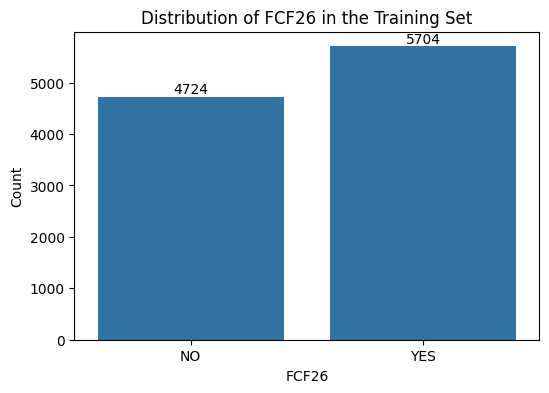

In [6]:
fcf_train_counts = train_df_full["FCF26"].value_counts().reset_index()
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train_df_full, x="FCF26")
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{int(height)}",
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontsize=10)

plt.title("Distribution of FCF26 in the Training Set")
plt.xlabel("FCF26")
plt.ylabel("Count")
plt.show()

## 2.3 Exploration of Missing Data Patterns
The proportion of missing values for each variable was further examined using the training set. As shown in the figure, there were clear differences in missingness across variables. In particular, CL3 had a missing rate of over 60%, while several other variables also showed moderate levels of missingness. Since variables with high missingness may increase the imputation uncertainty, a missingness threshold was applied during feature selection to remove variables with excessive missing values.

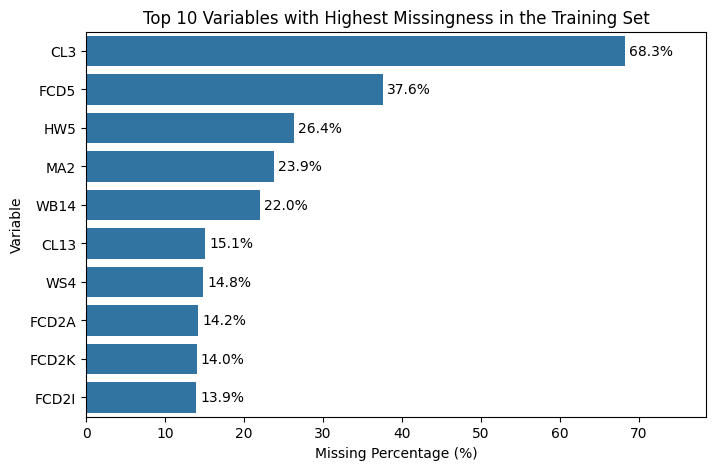

In [7]:
missing_rate_train = (
    train_df_full.drop(columns=[target_col]).isna().mean().sort_values(ascending=False)
)
top10_missing = missing_rate_train.head(10).reset_index()
top10_missing.columns = ["Variable", "MissingRate"]
top10_missing["MissingPercent"] = top10_missing["MissingRate"] * 100
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=top10_missing,x="MissingPercent",y="Variable")
for i, v in enumerate(top10_missing["MissingPercent"]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=10)
plt.title("Top 10 Variables with Highest Missingness in the Training Set")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Variable")
plt.xlim(0, max(top10_missing["MissingPercent"]) * 1.15)
plt.show()

## 2.4 Feature Selection
After splitting the dataset into training and test sets, feature selection was performed using only the training set. It aimed to reduce the influence of variables with high missingness and weak predictive information, thereby improving the stability and interpretability of the model.

**First, Feature Filtering Based on Missingness.** The proportion of missing values was calculated for each feature using the training set. Variables with more than 30% missing values were considered too incomplete and were therefore removed at this stage. According to the results, two features were excluded.


In [8]:
# feature screening
RANDOM_STATE = 42
missing_thresh = 0.30      
mi_thresh = 0.001          
chi2_p_thresh = 0.05       
# create copies to avoid modifying the original sets
train_df = train_df_full.copy()
test_df = test_df_full.copy()
assert target_col in train_df.columns, f"{target_col} not in train_df"
assert target_col in test_df.columns, f"{target_col} not in test_df"
# Separate features and target
y_train = train_df[target_col].copy()
y_test = test_df[target_col].copy()
X_train = train_df.drop(columns=[target_col]).copy()
X_test = test_df.drop(columns=[target_col]).copy()
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("target_col   :", target_col)

# missing rate filter based on train set
missing_rate = X_train.isna().mean().sort_values(ascending=False)
keep_by_missing = missing_rate[missing_rate <= missing_thresh].index.tolist()
drop_by_missing = missing_rate[missing_rate > missing_thresh].index.tolist()
X_train = X_train[keep_by_missing].copy()
X_test = X_test[keep_by_missing].copy()
print('Variables after missing rate filter')
print("Variables kept:", len(keep_by_missing))
print("Variables dropped:", len(drop_by_missing))
print("Variables dropped due to high missing rate:")
print(drop_by_missing)



X_train shape: (10428, 89)
X_test shape : (2608, 89)
target_col   : FCF26
Variables after missing rate filter
Variables kept: 87
Variables dropped: 2
Variables dropped due to high missing rate:
['CL3', 'FCD5']


Because different types of variables contain different information structures, a single filtering method was not applied to all variables. Numeric and ordinal variables can be represented in numeric form and were therefore filtered using mutual information (MI), while categorical variables were retained for the subsequent chi-square testing stage.

**Second,Mutual Information Filtering for Numeric and Ordinal Variables.** For variables with ordering, manually defined mapping rules were used to convert them into numeric form. This preserves the ordering information between categories, and allows these variables to be included more appropriately in the MI filtering step. MI was used for numeric and ordinal variables because it is better able to detect potential non-linear relationships compared with simple correlation analysis. A relatively low mutual information threshold of 0.001 was adopted to remove only variables that contributed almost no information. In total, 7 numeric and ordinal variables were retained for future analysis.


In [9]:
# Numeric / ordinal variable selection
numeric_vars_all = [
    "HH1", "HH2", "LN", "FS4",
    "CB3", "CL3", "CL13", "wscore", "WB4",
    "MA2", "LS2", "CSURV", "CDEAD"
]

# Manually define mapping rules for ordinal variables
ordinal_maps = {
    # child education
    "CB5A": {
        "NoSchool": 0,
        "ECE": 1,
        "PRIMARY": 2,
        "LOWER SECONDARY": 3,
        "UPPER SECONDARY": 4,
        "HIGHER": 5
    },
    # mother education
    "WB6A": {
        "NoSchool": 0,
        "ECE": 1,
        "PRIMARY": 2,
        "LOWER SECONDARY": 3,
        "UPPER SECONDARY": 4,
        "VOCATIONAL TRAINING": 5,
        "HIGHER": 6
    },
    # Child’s highest year of schooling completed
    "CB5B": {
        "0": 0,
        "CLASS/YEAR/GRADE 1": 1,
        "CLASS/YEAR/GRADE 2": 2,
        "CLASS/YEAR/GRADE 3": 3,
        "CLASS/YEAR/GRADE 4": 4,
        "CLASS/YEAR/GRADE 5": 5,
        "CLASS/GRADE 6": 6,
        "CLASS/GRADE 7": 7,
        "CLASS/GRADE 8": 8
    },
    # Mother’s highest year of schooling completed
    "WB6B": {
        "0": 0,
        "CLASS/YEAR/GRADE 1": 1,
        "CLASS/YEAR/GRADE 2": 2,
        "CLASS/YEAR/GRADE 3": 3,
        "CLASS/YEAR/GRADE 4": 4,
        "CLASS/YEAR/GRADE 5": 5,
        "CLASS/GRADE 6": 6,
        "CLASS/GRADE 7": 7,
        "CLASS/GRADE 8": 8
    },

    # Reading ability
    "WB14": {
        "CANNOT READ AT ALL": 0,
        "NO SENTENCE IN REQUIRED LANGUAGE / BRAILLE": 1,
        "ABLE TO READ ONLY PARTS OF SENTENCE": 2,
        "ABLE TO READ WHOLE SENTENCE": 3
    },

    # Functioning difficulties
    "AF10": {
        "NO DIFFICULTY": 0,
        "SOME DIFFICULTY": 1,
        "A LOT OF DIFFICULTY": 2
    },
    "AF11": {
        "NO DIFFICULTY": 0,
        "SOME DIFFICULTY": 1,
        "A LOT OF DIFFICULTY": 2
    },
    "AF12": {
        "NO DIFFICULTY": 0,
        "SOME DIFFICULTY": 1,
        "A LOT OF DIFFICULTY": 2,
        "NO RESPONSE": np.nan
    },
    # happiness and life changes
    "LS1": {
        "VERY UNHAPPY": 0,
        "SOMEWHAT UNHAPPY": 1,
        "NEITHER HAPPY NOR UNHAPPY": 2,
        "SOMEWHAT HAPPY": 3,
        "VERY HAPPY": 4
    },
    "LS3": {
        "WORSENED": 0,
        "MORE OR LESS THE SAME": 1,
        "IMPROVED": 2
    },
    "LS4": {
        "WORSE": 0,
        "MORE OR LESS THE SAME": 1,
        "BETTER": 2
    },
    # safety perception
    "VT20": {
        "VERY UNSAFE": 0,
        "UNSAFE": 1,
        "SAFE": 2,
        "VERY SAFE": 3,
        "NEVER WALK ALONE AFTER DARK": np.nan
    },
    "VT21": {
        "VERY UNSAFE": 0,
        "UNSAFE": 1,
        "SAFE": 2,
        "VERY SAFE": 3,
        "NEVER WALK ALONE AFTER DARK": np.nan
    }
    }

# define numeric and ordinal variables based on the above lists and mappings
numeric_vars = [c for c in numeric_vars_all if c in X_train.columns]
ordinal_vars = [c for c in ordinal_maps.keys() if c in X_train.columns]

# categorical variables 
categorical_vars = [
    c for c in X_train.columns
    if c not in numeric_vars + ordinal_vars
]
print("type of variables:")
print("numeric:", len(numeric_vars))
print("ordinal:", len(ordinal_vars))
print("categorical:", len(categorical_vars))

# map ordinal variables to numeric values
for col in ordinal_vars:
    mapping = ordinal_maps[col]
    X_train[col] = X_train[col].map(mapping)
    X_test[col] = X_test[col].map(mapping)

# true numeric variables: some may be read as object due to missing values or other issues, try to convert them to numeric
for col in numeric_vars:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

# MI filter for numeric and ordinal variables
selected_num_ord = []
num_ord_vars = numeric_vars + ordinal_vars

if len(num_ord_vars) > 0:
    X_train_num_ord = X_train[num_ord_vars].copy()
    mi_imputer = SimpleImputer(strategy="median")
    X_train_num_ord_imp = pd.DataFrame(
            mi_imputer.fit_transform(X_train_num_ord),
            columns=X_train_num_ord.columns,
            index=X_train_num_ord.index
        )

    mi_scores = mutual_info_classif(
            X_train_num_ord_imp,
            y_train.loc[X_train_num_ord_imp.index],
            random_state=RANDOM_STATE
        )

    mi_df = pd.DataFrame({
            "variable": X_train_num_ord_imp.columns,
            "mi_score": mi_scores
        }).sort_values("mi_score", ascending=False)

    selected_num_ord = mi_df.loc[
            mi_df["mi_score"] >= mi_thresh, "variable"
        ].tolist()

else:
    mi_df = pd.DataFrame(columns=["variable", "mi_score"])

print("round 2: MI scores for numeric and ordinal variables")
print(mi_df)
print('number of variables kept after MI filter:', len(selected_num_ord))
print("kept variables for numeric and ordinal:", selected_num_ord)

type of variables:
numeric: 12
ordinal: 13
categorical: 62
round 2: MI scores for numeric and ordinal variables
   variable  mi_score
0       HH1  0.037778
8       MA2  0.011984
16     WB14  0.007462
17     AF10  0.007045
20      LS1  0.006303
3       FS4  0.005829
11    CDEAD  0.005374
1       HH2  0.004207
19     AF12  0.003368
24     VT21  0.003153
2        LN  0.002908
21      LS3  0.002024
10    CSURV  0.001796
7       WB4  0.001652
13     WB6A  0.000793
23     VT20  0.000269
4       CB3  0.000047
5      CL13  0.000000
6    wscore  0.000000
9       LS2  0.000000
12     CB5A  0.000000
15     WB6B  0.000000
14     CB5B  0.000000
18     AF11  0.000000
22      LS4  0.000000
number of variables kept after MI filter: 14
kept variables for numeric and ordinal: ['HH1', 'MA2', 'WB14', 'AF10', 'LS1', 'FS4', 'CDEAD', 'HH2', 'AF12', 'VT21', 'LN', 'LS3', 'CSURV', 'WB4']


**Third,Chi-square Filtering for Categorical Variables**. The chi-square test was used because it is well suited to assess the dependence between categorical predictors and the binary outcome variable. To avoid data leakage, the chi-square test was conducted using only the training set. Variables with a p-value smaller than 0.05 were considered to have a statistically significant association with the target variable and were therefore retained for subsequent analysis.

In [10]:
# chi2 filter for categorical variables
selected_cat = []
chi2_results = []

for col in categorical_vars:
    tmp = pd.DataFrame({
        col: X_train[col],
        target_col: y_train
    }).dropna()
    contingency = pd.crosstab(tmp[col], tmp[target_col])
    # # Skip variables with too few categories or when the target has only one class
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        continue
    p_value = chi2_contingency(contingency)[1]
    chi2_results.append({
        "variable": col,
        "chi2_p_value": p_value
    })
    if p_value < chi2_p_thresh:
        selected_cat.append(col)
chi2_df = pd.DataFrame(chi2_results).sort_values("chi2_p_value", ascending=True)

print("results of chi2 test for categorical variables")
print(chi2_df)
print("kept variables for categorical:", selected_cat)

selected_features_first_round = selected_num_ord + selected_cat

print("selected features after first round of screening")
print("the number of selected features:", len(selected_features_first_round))
print(selected_features_first_round)
# check the types of the selected features
selected_numeric_vars = [c for c in selected_features_first_round if c in numeric_vars]
selected_ordinal_vars = [c for c in selected_features_first_round if c in ordinal_vars]
selected_categorical_vars = [c for c in selected_features_first_round if c in categorical_vars]
print('Final Retained Variable Types')
print("Numeric Variables:", selected_numeric_vars)
print("Ordinal Variables:", selected_ordinal_vars)
print("Categorical Variables:", selected_categorical_vars)

# generate screened datasets for subsequent modeling
train_screened = pd.concat(
    [X_train[selected_features_first_round], y_train],
    axis=1
).copy()

test_screened = pd.concat(
    [X_test[selected_features_first_round], y_test],
    axis=1
).copy()

print("\n=== Screened Data Shapes ===")
print("train_screened shape:", train_screened.shape)
print("test_screened shape :", test_screened.shape)



results of chi2 test for categorical variables
     variable  chi2_p_value
26      VT22A  1.347547e-24
19      VT22B  1.982790e-24
12      FCD2H  7.296946e-17
51  ethnicity  1.627987e-16
52        HH7  8.400827e-15
..        ...           ...
20        TA1  3.765489e-01
50        HL4  4.169002e-01
13        WS3  5.548244e-01
17       DV1A  6.014127e-01
25       DV1E  8.988885e-01

[62 rows x 2 columns]
kept variables for categorical: ['HW5', 'WS4', 'FCD2A', 'FCD2I', 'FCD2G', 'FCD2B', 'FCD2C', 'FCD2J', 'FCD2D', 'FCD2E', 'FCD2H', 'WS15', 'WS14', 'DV1B', 'VT22C', 'VT22B', 'VT1', 'DV1C', 'VT9', 'VT22A', 'TA14', 'VT22E', 'VT22D', 'VT22X', 'VT22F', 'disability', 'WB5', 'MA3', 'HC19', 'HC11', 'HC13', 'WS7', 'HC8', 'HC12', 'WS11', 'HC14', 'ethnicity', 'HH7', 'MSTATUS', 'CL2', 'CL12', 'HC4', 'HC5', 'WS1', 'MA2_status', 'CL3_status', 'CL13_status']
selected features after first round of screening
the number of selected features: 61
['HH1', 'MA2', 'WB14', 'AF10', 'LS1', 'FS4', 'CDEAD', 'HH2', 'AF

**Forth, Manual feature refinement**. After completing the feature selection based on missingness, MI and chi-square testing, a manual adjustment step was performed by considering the variable meanings and questionnaire structure. The purpose of this step was to address the limitations of purely statistical selection methods, ensuring that the final set of variables was both statistically relevant and interpretable.

Several victimization-related variables were removed. These variables overlapped strongly with others in the same group and showed weaker statistical significance, so they were not included in the final modelling variable set. The variable CL3_status was also removed because the original variable CL3 had already been excluded during feature selection, making CL3_status no longer meaningful to retain.

In addition, several variables with important theoretical relevance were manually retained. These variables function as prerequisite variables within the questionnaire structure. Removing such variables while retaining their subsequent related variables could weaken the interpretability. Therefore, these variables were preserved during the feature selection process.

In [11]:
# Further manual adjustments 
# based on the results of the first round of feature screening.

manual_drop_vars = [
    "VT22A", "VT22B", "VT22C", "VT22D", "VT22E", "VT22F", "VT22X",'CL3_status'
]

theory_add_vars = [
    "CB3",
    "wscore",
    "CB4"
]
manual_drop_vars = [v for v in manual_drop_vars if v in selected_features_first_round]
theory_add_vars = [
    v for v in theory_add_vars
    if (v in train_df_full.columns)
    and (v in test_df_full.columns)
    and (v != target_col)
]
manual_add_vars = sorted(set(theory_add_vars))

# select the final features after manual adjustments
selected_features_final = [
    v for v in selected_features_first_round
    if v not in manual_drop_vars
]

for v in manual_add_vars:
    if v not in selected_features_final:
        selected_features_final.append(v)

print("final features after manual adjustments:", len(selected_features_final))
print(selected_features_final)

# generate final train/test sets based on the full data and the final selected features
train_df = train_df_full[selected_features_final + [target_col]].copy()
test_df = test_df_full[selected_features_final + [target_col]].copy()
print("train_df shape:", train_df.shape)
print("test_df shape :", test_df.shape)
train_df.isna().sum().sort_values(ascending=False).head(20)

final features after manual adjustments: 56
['HH1', 'MA2', 'WB14', 'AF10', 'LS1', 'FS4', 'CDEAD', 'HH2', 'AF12', 'VT21', 'LN', 'LS3', 'CSURV', 'WB4', 'HW5', 'WS4', 'FCD2A', 'FCD2I', 'FCD2G', 'FCD2B', 'FCD2C', 'FCD2J', 'FCD2D', 'FCD2E', 'FCD2H', 'WS15', 'WS14', 'DV1B', 'VT1', 'DV1C', 'VT9', 'TA14', 'disability', 'WB5', 'MA3', 'HC19', 'HC11', 'HC13', 'WS7', 'HC8', 'HC12', 'WS11', 'HC14', 'ethnicity', 'HH7', 'MSTATUS', 'CL2', 'CL12', 'HC4', 'HC5', 'WS1', 'MA2_status', 'CL13_status', 'CB3', 'CB4', 'wscore']
train_df shape: (10428, 57)
test_df shape : (2608, 57)


HW5      2753
MA2      2489
WB14     2292
WS4      1547
FCD2A    1479
FCD2I    1454
FCD2G    1449
FCD2B    1448
FCD2C    1448
FCD2J    1446
FCD2E    1445
FCD2D    1445
FCD2H    1444
WS15      769
WS14      763
DV1B      268
VT1       254
DV1C      253
VT9       250
VT21      246
dtype: int64

To provide a more intuitive understanding of the selected features, the relationship between a selected variable('wscore') and target variable('FCF26') was visualized. From the figure, children classified as experiencing depressive feelings (“YES”) tend to have slightly lower wealth scores on average compared with those without depressive feelings (“NO”).

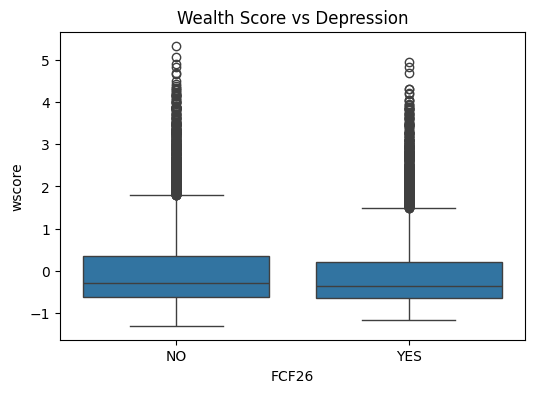

In [12]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    x=train_df[target_col],
    y=train_df["wscore"]
)
plt.title("Wealth Score vs Depression")
plt.show()

## 2.5 Preprocessing Pipeline Design
After feature selection, a preprocessing pipeline was needed for later modelling. Since the final variables included both numeric and categorical features, different methods were applied to different variable types. For numeric variables, missing values were first imputed using the median, and standardization was then applied after imputation. This was especially important for the later logistic regression models. For categorical variables, missing values were imputed using the most frequent category, followed by one-hot encoding. Finally, a unified pipeline was used to ensure consistent preprocessing for both the training set and the test set.

In [13]:
random_state = 42
baseline_vars = selected_features_final
X_train = train_df[baseline_vars].copy()
y_train = train_df[target_col].copy()
X_test = test_df[baseline_vars].copy()
y_test = test_df[target_col].copy()

# recode target variable to numeric
label_map = {
    "NO": 0,
    "YES": 1
}
y_train = train_df[target_col].map(label_map)
y_test = test_df[target_col].map(label_map)

# identify numeric and categorical variables based on the train set
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [col for col in X_train.columns if col not in numeric_cols]
for col in categorical_cols:
    X_train[col] = X_train[col].where(X_train[col].isna(), X_train[col].astype(str))
    X_test[col] = X_test[col].where(X_test[col].isna(), X_test[col].astype(str))

# preprocessor for numeric and categorical variables
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Model Fitting and Tuning

*In this section you should detail and motivate your choice of model and describe the process used to refine, tune, and fit that model. You are encouraged to explore different models but you should NOT include a detailed narrative or code of all of these attempts. At most this section should very briefly mention the methods explored and why they were rejected - most of your effort should go into describing the final model you are using and your process for tuning and validating it.*

*This section should include the full implementation of your final model, including all necessary validation. As with figures, any included code must also be addressed in the text of the document.*

*You should also include a baseline model of your choice and provide a comparison of your model with the baseline model on the test data. You should briefly describe the baseline model considered.*

## 3.1 Baseline Model
As a starting point, we use a standard logistic regression model as a baseline. This provides a simple and interpretable reference that we can later compare with more refined models.

Let $Y \in \{0,1\}$ denote the binary outcome. The model is given by:

$$\text{logit}(P(Y = 1 \mid X)) = \beta_0 + \sum_{j=1}^{p} \beta_j X_j$$

Before fitting the model, all variables are processed through a preprocessing pipeline. Numerical variables are standardised to ensure they are on a comparable scale, while categorical variables are converted into dummy variables so that they can be used in the logistic regression model. This preprocessing step ensures that all predictors are in a suitable numerical form for model estimation.

The model is implemented using the LogisticRegression class with the lbfgs solver. We set a very large value for the regularisation parameter ($C = \infty$), so that the model is effectively unregularised. A relatively large number of iterations ($max\_iter=5000$) is used to reduce the risk of non-convergence during optimisation.

In [17]:
# Baseline Logistic Regression
baseline_model = LogisticRegression(
    C=np.inf,
    solver="lbfgs",
    max_iter=5000,
    random_state=random_state
)

baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", baseline_model)
])

baseline_pipeline.fit(X_train, y_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [18]:
# 评估函数
def evaluate_model(model, X, y):

    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    return {
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y, y_prob)
    }, y_pred, y_prob


baseline_train_metrics, baseline_train_pred, baseline_train_prob = evaluate_model(
    baseline_pipeline, X_train, y_train
)

baseline_test_metrics, baseline_test_pred, baseline_test_prob = evaluate_model(
    baseline_pipeline, X_test, y_test
)


baseline_perf_df = pd.DataFrame(
    [baseline_train_metrics, baseline_test_metrics],
    index=["train", "test"]
)

print("\nBaseline表现：")
display(baseline_perf_df)

# 提取系数
feature_names_after_encoding = baseline_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

baseline_coef_df = pd.DataFrame({
    "feature": feature_names_after_encoding,
    "coef": baseline_pipeline.named_steps["model"].coef_[0]
}).sort_values("coef", key=np.abs, ascending=False)

display(baseline_coef_df.head(20))

# 预测结果（供后续cell使用）
baseline_train_pred_df = pd.DataFrame({
    "y_true": y_train,
    "y_pred": baseline_train_pred,
    "y_prob": baseline_train_prob
})

baseline_test_pred_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": baseline_test_pred,
    "y_prob": baseline_test_prob
})


Baseline表现：


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
train,0.627733,0.616451,0.63845,0.736501,0.683979,0.667250
test,0.606595,0.594524,0.62071,0.722495,0.667746,0.632873


,feature,coef
110,cat__WS4_13.0,-6.841019
145,cat__WS4_34.0,-5.883630
284,cat__HC5_ROOFING SHINGLES,-4.693573
128,cat__WS4_21.0,-4.671056
68,cat__MA2_72.0,-4.464128
112,cat__WS4_135.0,4.463888
69,cat__MA2_73.0,-4.411792
76,cat__MA2_80.0,4.226235
165,cat__WS4_610.0,-3.605173
156,cat__WS4_46.0,-3.236737


To evaluate performance, we consider several metrics, including accuracy, balanced accuracy, precision, recall, F1-score, and ROC-AUC. These metrics provide a more comprehensive assessment of model performance, as they capture different aspects of classification quality, such as the trade-off between precision and recall, and the model’s ability to discriminate between classes.

On the test data, the baseline model achieves an accuracy of 0.607 and a ROC-AUC of 0.633. While this shows that the model has some predictive power, the performance is still limited. In addition, using a large number of features without regularisation may increase the risk of overfitting and makes the model more difficult to interpret. For this reason, we consider a regularised logistic regression model in the next section.

## 3.2 Final Model Specification
To improve upon the baseline model, we consider a regularised logistic regression model with an L1 penalty. This choice is motivated in part by the relatively large number of predictors after preprocessing, particularly due to the expansion of categorical variables into dummy variables. In this setting, regularisation helps control model complexity and improves interpretability.

The model follows the same logistic regression formulation as the baseline model, but with an additional L1 penalty applied to the coefficients:

$$\min_{\beta} \left\{
- \ell(\beta) + \lambda \sum_{j=1}^{p} |\beta_j|
\right\}$$

where $\ell(\beta)$ denotes the log-likelihood. This penalty encourages sparse solutions, where some coefficients are shrunk to zero, effectively performing variable selection.

The model is implemented using LogisticRegressionCV, which allows the regularisation strength to be selected via cross-validation over a predefined grid of values. An elastic net formulation is used with l1\_ratio = 1, which corresponds to L1 regularisation. The saga solver is used as it supports L1 regularisation and is suited for high-dimensional settings.

The model is fitted within a pipeline that includes the same preprocessing steps as the baseline model. This allows transformations to be applied consistently during both training and evaluation.

The implementation is shown below.

In [16]:
Cs_grid = np.logspace(-2, 2, 30)

# 使用手动筛选变量
final_vars = selected_features_final
X_train = train_df[final_vars].copy()
y_train = train_df[target_col].map({"NO": 0, "YES": 1}).copy()

X_test = test_df[final_vars].copy()
y_test = test_df[target_col].map({"NO": 0, "YES": 1}).copy()

print("进入 Final(L1) 的变量数:", len(final_vars))

# 识别变量类型
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [col for col in X_train.columns if col not in numeric_cols]
X_train[categorical_cols] = X_train[categorical_cols].astype(str)
X_test[categorical_cols] = X_test[categorical_cols].astype(str)

# Final：L1 LogisticRegressionCV
final_model = LogisticRegressionCV(
    Cs=Cs_grid,
    cv=5,
    penalty="elasticnet",
    l1_ratios=[1.0],   # 等价于 L1
    solver="saga",
    scoring="roc_auc",
    max_iter=8000,
    random_state=random_state,
    n_jobs=-1,
    refit=True
)

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_model)
])

final_pipeline.fit(X_train, y_train)

进入 Final(L1) 的变量数: 56


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 3.3 Model Tuning and Validation
The regularisation strength in the L1-regularised logistic regression model is selected using cross-validation. Specifically, a grid of candidate values for the regularisation parameter $C$ is defined on a logarithmic scale:

$$
C \in \{0.01, \dots, 100\}
$$

For each candidate value of $C$, a 5-fold cross-validation procedure is used to evaluate model performance. The model performance is evaluated using the ROC-AUC score, which is a threshold-independent measure of discrimination ability for binary classification problems.

The value of $C$ that maximises the mean cross-validated ROC-AUC is selected as the optimal tuning parameter. The final model is then refitted on the full training data using this parameter, as implemented within the LogisticRegressionCV procedure. The selected value of $C$ is reported as part of the final model output.

In [20]:
best_C_final = final_pipeline.named_steps["model"].C_[0]
print("\nFinal(L1)最优 C:", best_C_final)


Final(L1)最优 C: 0.12689610031679222


## 3.4 Model Performance Comparison

In [21]:
# 评估函数
def evaluate_model(model, X, y):

    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    return {
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y, y_prob)
    }, y_pred, y_prob


final_train_metrics, final_train_pred, final_train_prob = evaluate_model(
    final_pipeline, X_train, y_train
)

final_test_metrics, final_test_pred, final_test_prob = evaluate_model(
    final_pipeline, X_test, y_test
)


final_perf_df = pd.DataFrame(
    [final_train_metrics, final_test_metrics],
    index=["train", "test"]
)

print("\nFinal(L1)表现：")
display(final_perf_df)

# 提取 L1 非零变量
feature_names_after_encoding = final_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

coefs = final_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature_after_encoding": feature_names_after_encoding,
    "coefficient": coefs,
    "abs_coefficient": np.abs(coefs)
})

selected_coef_df = coef_df[coef_df["coefficient"] != 0].copy()

selected_coef_df = selected_coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)


# 还原到原始变量层面

original_feature_names = X_train.columns.tolist()


def recover_original_variable(encoded_name):

    if encoded_name.startswith("num__"):
        return encoded_name.replace("num__", "")

    elif encoded_name.startswith("cat__"):

        temp = encoded_name.replace("cat__", "")

        sorted_cols = sorted(
            original_feature_names,
            key=len,
            reverse=True
        )

        for col in sorted_cols:

            if temp == col or temp.startswith(col + "_"):
                return col

        return temp

    else:
        return encoded_name


selected_coef_df["original_variable"] = selected_coef_df[
    "feature_after_encoding"
].apply(recover_original_variable)


final_original_vars = selected_coef_df[
    "original_variable"
].drop_duplicates().tolist()


print("\nL1筛选后保留下来的变量数:", len(final_original_vars))

display(final_original_vars)

# 预测结果（供后续 cell 使用）
final_train_pred_df = pd.DataFrame({
    "y_true": y_train,
    "y_pred": final_train_pred,
    "y_prob": final_train_prob
})

final_test_pred_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": final_test_pred,
    "y_prob": final_test_prob
})


Final(L1)表现：


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
train,0.618911,0.606604,0.629414,0.737553,0.679206,0.653631
test,0.614264,0.601240,0.624630,0.739313,0.677150,0.640721



L1筛选后保留下来的变量数: 48


['WS7',
 'AF10',
 'ethnicity',
 'LS1',
 'VT21',
 'WS4',
 'VT1',
 'HH7',
 'WS14',
 'MA2',
 'FCD2H',
 'CL2',
 'LS3',
 'WS11',
 'CL12',
 'HW5',
 'HC8',
 'wscore',
 'WS1',
 'FCD2E',
 'MA2_status',
 'FCD2D',
 'MA3',
 'FCD2B',
 'DV1B',
 'TA14',
 'HH1',
 'WB14',
 'MSTATUS',
 'HC12',
 'WS15',
 'CB3',
 'FCD2A',
 'WB4',
 'VT9',
 'FCD2C',
 'FCD2J',
 'HC14',
 'HC13',
 'HC4',
 'HH2',
 'CL13_status',
 'DV1C',
 'CDEAD',
 'FS4',
 'LN',
 'disability',
 'CSURV']

# Interpretation, Discussion & Conclusions

*In this section you should provide a general overview of your final model, its performance, and reliability. You should discuss what the implications of your model are in terms of the included features, estimated parameters and relationships, predictive performance, and anything else you think is relevant.*

*This should be written with a target audience of a government official, who understands the issues associated with mental health but may only have university level mathematics (not necessarily postgraduate statistics or machine learning). Your goal should be to highlight to this audience how your model can useful. You should also discuss potential limitations or directions of future improvement of your model.*

*Finally, you should include recommendations on factors that may increase the risk of depression, which may be useful for the government officials and health care workers to improve their understanding of the condition, and potentially assit in the development of effective social and health policies and interventions.*

*Keep in mind that a negative result, i.e. a model that does not work well predictively, that is well explained and justified in terms of why it failed will likely receive higher marks than a model with strong predictive performance but with poor or incorrect explanations / justifications.*

# Generative AI statement

*Include a statement on how generative AI was used in the project and report.*

# References

*Include references if any*

In [ ]:
# Run the following to render to PDF
!jupyter nbconvert --to pdf project.ipynb